# 롤 API 데이터 수집하기

In [9]:
import requests
import json
import time
import numpy as np
import pandas as pd

## API를 통한 소환사 정보 수집

In [10]:
# Lol Api에서 소환사 명을 통해서 게임 정보를 알 수 있는 puuid 불러오기 
summoner_Name = 'one summer drive' #소환사명
api_key = "RGAPI-02ea02a9-115e-404f-a734-f2661999ff10" # api key
request_headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/103.0.0.0 Safari/537.36",
    "Accept-Language": "ko-KR,ko;q=0.9,en-US;q=0.8,en;q=0.7",
    "Accept-Charset": "application/x-www-form-urlencoded; charset=UTF-8",
    "Origin": "https://developer.riotgames.com",
    "X-Riot-Token": "RGAPI-02ea02a9-115e-404f-a734-f2661999ff10"
}

summoner_url="https://kr.api.riotgames.com/lol/summoner/v4/summoners/by-name/"+summoner_Name+"/""?api_key="+api_key

In [11]:
# requests를 통해서 puuid 추출하기
def summoner(summoner_Name, api_key):
    summoner_url = "https://kr.api.riotgames.com/lol/summoner/v4/summoners/by-name/"+summoner_Name+"/""?api_key="+api_key
    return requests.get(summoner_url, headers=request_headers).json()['puuid']
summoner_puuid = summoner(summoner_Name, api_key)
summoner_puuid

'cQ5NsmQunQmf0Lo8WMNEx7PZpGwr5g6sbqBmYt2hYIt-72J0XfluBWZsNURa-_rKA5AR_vMndVW8tg'

In [12]:
# match id를 확인할 수 있는 api를 통해서 조회하기
# match_count : 조회하고 싶은 매치의 수
# 더 많이 조회를 하고 싶으나 횟수 제한이 있다. (100) 이번 시즌 내가 플레이한 62게임에 대해서 조사하기 
def match(summoner_puuid, match_count):
    match_url = "https://asia.api.riotgames.com/lol/match/v5/matches/by-puuid/"+summoner_puuid+"/ids?start=0&count="+str(match_count)
    return requests.get(match_url, headers=request_headers).json()
match_id = match(summoner_puuid, 90)
match_id

['KR_6028067770',
 'KR_6027167940',
 'KR_6027078402',
 'KR_6026959324',
 'KR_6026550378',
 'KR_6026049230',
 'KR_6025776447',
 'KR_6025626879',
 'KR_6024617209',
 'KR_6024522598',
 'KR_6024290118',
 'KR_6024206432',
 'KR_6018696284',
 'KR_6018287979',
 'KR_6017207879',
 'KR_6017033024',
 'KR_6016828310',
 'KR_6016772762',
 'KR_6016770544',
 'KR_6016651859',
 'KR_6016575318',
 'KR_6015787618',
 'KR_6015488822',
 'KR_6015088138',
 'KR_6014287649',
 'KR_6012864614',
 'KR_6012476838',
 'KR_6011712595',
 'KR_6011597486',
 'KR_6010856241',
 'KR_6009908963',
 'KR_6009876008',
 'KR_6009892943',
 'KR_6009828517',
 'KR_6009775487',
 'KR_6009753833',
 'KR_6008388001',
 'KR_6008101825',
 'KR_6007718428',
 'KR_6007632404',
 'KR_6007543140',
 'KR_6007407898',
 'KR_6007030534',
 'KR_6006751091',
 'KR_6006310180',
 'KR_6006082114',
 'KR_6005589922',
 'KR_6005521617',
 'KR_6005292412',
 'KR_6004906534',
 'KR_6002949666',
 'KR_6002335329',
 'KR_6000663825',
 'KR_6000095173',
 'KR_5995456456',
 'KR_59938

In [13]:
# 게임 세부내용 불러오기
# 조회는 하나씩만 가능하므로 for문이나 while문을 돌려 하나씩 조회한다.
def game(match_id_num):
    game_url = "https://asia.api.riotgames.com/lol/match/v5/matches/"+match_id_num
    return requests.get(game_url, headers=request_headers).json()['info']['participants']


## 분석에 사용할 90개의 데이터 수집하여 데이터 프레임 생성
- 100개로 하고 돌렸으나 API응답문제가 발생하였다

In [14]:
#Future Warning 메세지 제거하기
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# 게임 데이터를 담을 DataFrame 생성하기
game_df = pd.DataFrame(columns=['puuid', 'teamPosition', 'individualPosition', 'champName', 'champExp', 'summoner_spell1', 'summoner_spell2' ,
                                'kills', 'deaths', 'assists', 'damageDealtToBuildings', 'totalDamageDealtToChamp', 'damagePerMin', 'teamDamagePer(%)',
                                'killParticipation(%)', 'totalDamageTaken', 'damageTakeOnTeamPer(%)', 'goldEarned', 'goldPerMin', 'totalCs',
                                'maxCsAdvantageOnLaneOpponent', 'maxLevelLeadLaneOpponent', 'gameEndedInEarlySurren', 'gameEndedInSurren',
                                'teamEarlySurrn', 'timePlayed'])

for i in range(len(match_id)):
    game_content = game(match_id[i])
    for j in range(len(game_content)):
        try:
            input_data = {

                'puuid':game_content[j]['puuid'], 
                'teamPosition':game_content[j]['teamPosition'], 
                'individualPosition':game_content[j]['individualPosition'], 
                'champName':game_content[j]['championName'], 
                'champExp':float(game_content[j]['champExperience']), 
                'summoner_spell1':float(game_content[j]['summoner1Id']), 
                'summoner_spell2':float(game_content[j]['summoner2Id']),
                'kills':float(game_content[j]['kills']), 
                'deaths':float(game_content[j]['deaths']), 
                'assists':float(game_content[j]['assists']), 
                'damageDealtToBuildings':float(game_content[j]['damageDealtToBuildings']), 
                'totalDamageDealtToChamp':float(game_content[j]['totalDamageDealtToChampions']),
                'damagePerMin':game_content[j]['challenges']['damagePerMinute'], 
                'teamDamagePer(%)':round(game_content[j]['challenges']['teamDamagePercentage'], 2)*100,
                'killParticipation(%)':game_content[j]['challenges']['killParticipation']*100,
                'totalDamageTaken':float(game_content[j]['totalDamageTaken']),
                'damageTakeOnTeamPer(%)':round(game_content[j]['challenges']['damageTakenOnTeamPercentage'],2)*100,
                'goldEarned':float(game_content[j]['goldEarned']),
                'goldPerMin':game_content[j]['challenges']['goldPerMinute'],
                'totalCs':float(game_content[j]['totalMinionsKilled']+game_content[j]['neutralMinionsKilled']),
                'maxCsAdvantageOnLaneOpponent':float(game_content[j]['challenges']['maxCsAdvantageOnLaneOpponent']),
                'maxLevelLeadLaneOpponent':float(game_content[j]['challenges']['maxLevelLeadLaneOpponent']),
                'gameEndedInEarlySurren':game_content[j]['gameEndedInEarlySurrender'],
                'gameEndedInSurren':game_content[j]['gameEndedInSurrender'],
                'teamEarlySurrn':game_content[j]['teamEarlySurrendered'],
                'timePlayed':float(round(game_content[j]['timePlayed']/60,2)*100) # 4자리로 앞의 2자리는 분, 뒤의 2자리는 초로 구성되어있다. 
                }
            game_df = game_df.append(input_data, ignore_index=True)
        except:
            input_data = {

                'puuid':game_content[j]['puuid'], 
                'teamPosition':game_content[j]['teamPosition'], 
                'individualPosition':game_content[j]['individualPosition'], 
                'champName':game_content[j]['championName'], 
                'champExp':float(game_content[j]['champExperience']), 
                'summoner_spell1':float(game_content[j]['summoner1Id']), 
                'summoner_spell2':float(game_content[j]['summoner2Id']),
                'kills':float(game_content[j]['kills']), 
                'deaths':float(game_content[j]['deaths']), 
                'assists':float(game_content[j]['assists']), 
                'damageDealtToBuildings':float(game_content[j]['damageDealtToBuildings']), 
                'totalDamageDealtToChamp':float(game_content[j]['totalDamageDealtToChampions']),
                'damagePerMin':game_content[j]['challenges']['damagePerMinute'], 
                'teamDamagePer(%)':round(game_content[j]['challenges']['teamDamagePercentage'], 2)*100,
                'killParticipation(%)':game_content[j]['challenges']['killParticipation']*100,
                'totalDamageTaken':float(game_content[j]['totalDamageTaken']),
                'damageTakeOnTeamPer(%)':round(game_content[j]['challenges']['damageTakenOnTeamPercentage'],2)*100,
                'goldEarned':float(game_content[j]['goldEarned']),
                'goldPerMin':game_content[j]['challenges']['goldPerMinute'],
                'totalCs':float(game_content[j]['totalMinionsKilled']+game_content[j]['neutralMinionsKilled']),
                'maxCsAdvantageOnLaneOpponent':0,
                'maxLevelLeadLaneOpponent':0,
                'gameEndedInEarlySurren':game_content[j]['gameEndedInEarlySurrender'],
                'gameEndedInSurren':game_content[j]['gameEndedInSurrender'],
                'teamEarlySurrn':game_content[j]['teamEarlySurrendered'],
                'timePlayed':float(round(game_content[j]['timePlayed']/60,2)*100) # 4자리로 앞의 2자리는 분, 뒤의 2자리는 초로 구성되어있다. 
                }
            game_df = game_df.append(input_data, ignore_index=True) 

In [15]:
game_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   puuid                         900 non-null    object 
 1   teamPosition                  900 non-null    object 
 2   individualPosition            900 non-null    object 
 3   champName                     900 non-null    object 
 4   champExp                      900 non-null    float64
 5   summoner_spell1               900 non-null    float64
 6   summoner_spell2               900 non-null    float64
 7   kills                         900 non-null    float64
 8   deaths                        900 non-null    float64
 9   assists                       900 non-null    float64
 10  damageDealtToBuildings        900 non-null    float64
 11  totalDamageDealtToChamp       900 non-null    float64
 12  damagePerMin                  900 non-null    float64
 13  teamD

In [16]:
game_df

,puuid,teamPosition,individualPosition,champName,champExp,summoner_spell1,summoner_spell2,kills,deaths,assists,...,damageTakeOnTeamPer(%),goldEarned,goldPerMin,totalCs,maxCsAdvantageOnLaneOpponent,maxLevelLeadLaneOpponent,gameEndedInEarlySurren,gameEndedInSurren,teamEarlySurrn,timePlayed
0,cQ5NsmQunQmf0Lo8WMNEx7PZpGwr5g6sbqBmYt2hYIt-72...,TOP,TOP,Gangplank,19408.0,4.0,12.0,10.0,8.0,13.0,...,21.0,17849.0,421.685148,244.0,60.50,2.0,False,True,False,4232.0
1,0kedo_Z0hSTCdLBab3ZX5OHYAGYJB0S1Uisq3MeHhduZb3...,JUNGLE,JUNGLE,Zac,16696.0,11.0,4.0,6.0,9.0,13.0,...,27.0,13151.0,310.714901,180.0,16.40,2.0,False,True,False,4232.0
2,fw5AVwClGinSe1yX4Q0KDXQmN_AKvaplrtLZPlAfQo_Qon...,MIDDLE,MIDDLE,Fizz,19837.0,4.0,14.0,4.0,11.0,12.0,...,20.0,14959.0,353.409917,242.0,3.00,1.0,False,True,False,4232.0
3,aCLRuB-e8s3f5WXHV5purQAXqXptB_f_oGAvMlvtk_xs5B...,BOTTOM,BOTTOM,Vayne,19489.0,7.0,4.0,8.0,7.0,15.0,...,18.0,16359.0,386.490705,222.0,3.00,1.0,False,True,False,4232.0
4,grP1E5lVZk3EPgXWGVzkqnGWS48iAx2Fr8ts7bRCxIlgup...,UTILITY,UTILITY,Morgana,13787.0,14.0,4.0,4.0,8.0,18.0,...,13.0,11742.0,277.412282,49.0,15.25,1.0,False,True,False,4232.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,o_CyUnsIeyTmWDyceQeymkH7WjaMmIyrHm2B-x8fPWgFEP...,,Invalid,Viego,12106.0,32.0,4.0,15.0,7.0,12.0,...,28.0,12196.0,937.593424,22.0,5.00,1.0,False,False,False,1300.0
896,Oe5_4xFkWJR28-6nz10J4qBOPiNt2hsMNb2_6_dV1Md0Qn...,,Invalid,Nautilus,12846.0,6.0,4.0,2.0,8.0,32.0,...,22.0,9188.0,706.332316,22.0,0.00,1.0,False,False,False,1300.0
897,kUrU6_cLCrPIc2YMEWQkbuf08UxZQZc9XB8FwdDr35kp1O...,,Invalid,Diana,11564.0,32.0,4.0,9.0,7.0,17.0,...,18.0,9931.0,763.483988,18.0,4.00,1.0,False,False,False,1300.0
898,XNRc_pI2Fe1qHyZRp6w3RoVeeq6_jOdvaZBY09E8F01gmO...,,Invalid,Graves,13509.0,32.0,4.0,14.0,7.0,16.0,...,20.0,12479.0,959.334910,54.0,1.00,1.0,False,False,False,1300.0


## 가설 확인하기

```
인게임 속의 트롤링은 처음부터 발생할 수도 있고 중간에 소환사의 변심으로 인해서 발생할 수도 있고 수 많은 경우로 인해 발생한다.
기본적으로 의도적인 죽음, 다른 소환사들 방해, 한타에 합류를 하지 않거나, 우물에서 잠수를 하거나 
위와 같은 행위들은 기본적으로 DPM의 하락을 가져온다. 또한 안정적으로 성장을 한 상대 라이너에 비해서 성장 측면에서 많은 차이가 나타난다. 

픽창에서의 싸움으로 인한 소환사 스펠, 주 포지션이 아니므로 인한 트롤 등에 대해서는 소환사 스펠을 통해서 확인한다. 
```

- 가장 최근 게임의 트롤은 워익이었다. 
- 욕설과 함께 한타참여X, 정글링만 하거나, 우물에서 잠수 
- 딜량에 대해서 수치화 하기 
- 게임은 빠른 서렌이 나오는 15분부터 끝나기 시작한다.
- 15분까지는 기본적으로 라인전이 끝나는 시기, 탑, 미드, 바텀의 경우에는 라인전을 통해서 딜량을 쌓을수 있으나 정글의 경우에는 힘들다. 
- 게임이 장기간으로 가는경우 서포터는 딜량이 작기 마련이다. 
- 원딜의 경우에는 코어가 뜨면 뜰 수록 강해진다. 
- 위와 같은 경우를 수치화 조정해서 딜량을 계산한다.

## Match에 포함되어 있는 칼바람, 일반게임 정보 제거하기 

In [17]:
# 포지션에 Top, Jungle, Middle, Botoom, Utility 이외의 공백인 행들이 일반게임, 칼바람나락의 결과
game_df['teamPosition'].unique()

array(['TOP', 'JUNGLE', 'MIDDLE', 'BOTTOM', 'UTILITY', ''], dtype=object)

In [18]:
game_df['teamPosition']==''.index

0      False
1      False
2      False
3      False
4      False
       ...  
895    False
896    False
897    False
898    False
899    False
Name: teamPosition, Length: 900, dtype: bool

In [19]:
# 포지션 선택이 없는 게임 제거하기
# 29게임이 제외되었다. 
game_df = game_df.drop(game_df[game_df['teamPosition']==''].index, axis=0).reset_index(drop=True)
game_df

,puuid,teamPosition,individualPosition,champName,champExp,summoner_spell1,summoner_spell2,kills,deaths,assists,...,damageTakeOnTeamPer(%),goldEarned,goldPerMin,totalCs,maxCsAdvantageOnLaneOpponent,maxLevelLeadLaneOpponent,gameEndedInEarlySurren,gameEndedInSurren,teamEarlySurrn,timePlayed
0,cQ5NsmQunQmf0Lo8WMNEx7PZpGwr5g6sbqBmYt2hYIt-72...,TOP,TOP,Gangplank,19408.0,4.0,12.0,10.0,8.0,13.0,...,21.0,17849.0,421.685148,244.0,60.50,2.0,False,True,False,4232.0
1,0kedo_Z0hSTCdLBab3ZX5OHYAGYJB0S1Uisq3MeHhduZb3...,JUNGLE,JUNGLE,Zac,16696.0,11.0,4.0,6.0,9.0,13.0,...,27.0,13151.0,310.714901,180.0,16.40,2.0,False,True,False,4232.0
2,fw5AVwClGinSe1yX4Q0KDXQmN_AKvaplrtLZPlAfQo_Qon...,MIDDLE,MIDDLE,Fizz,19837.0,4.0,14.0,4.0,11.0,12.0,...,20.0,14959.0,353.409917,242.0,3.00,1.0,False,True,False,4232.0
3,aCLRuB-e8s3f5WXHV5purQAXqXptB_f_oGAvMlvtk_xs5B...,BOTTOM,BOTTOM,Vayne,19489.0,7.0,4.0,8.0,7.0,15.0,...,18.0,16359.0,386.490705,222.0,3.00,1.0,False,True,False,4232.0
4,grP1E5lVZk3EPgXWGVzkqnGWS48iAx2Fr8ts7bRCxIlgup...,UTILITY,UTILITY,Morgana,13787.0,14.0,4.0,4.0,8.0,18.0,...,13.0,11742.0,277.412282,49.0,15.25,1.0,False,True,False,4232.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735,izkdkzth-nRWiGU1ssUGwGOZSmIx3E0CnVw8TvmCdbADRI...,TOP,TOP,Lucian,10465.0,12.0,4.0,5.0,2.0,3.0,...,21.0,9242.0,512.974362,160.0,63.00,2.0,False,True,False,1800.0
736,GLUb-YiZWPONWpR3wd4E7w17Qmez0-Zowkk-ZmbdchnAAL...,JUNGLE,JUNGLE,Viego,8087.0,11.0,4.0,5.0,4.0,3.0,...,35.0,7629.0,423.453881,97.0,28.00,2.0,False,True,False,1800.0
737,QOU8VObhOsaqbkB3fo8RhBWfhSnBlA6eL6LN5VMP3rl9I3...,MIDDLE,MIDDLE,Lissandra,9822.0,12.0,4.0,7.0,1.0,3.0,...,20.0,8856.0,491.572199,133.0,44.00,2.0,False,True,False,1800.0
738,cQ5NsmQunQmf0Lo8WMNEx7PZpGwr5g6sbqBmYt2hYIt-72...,BOTTOM,BOTTOM,Jhin,6736.0,4.0,7.0,1.0,1.0,6.0,...,10.0,7273.0,403.683500,147.0,35.00,1.0,False,True,False,1800.0


### Play시간대 별로 나누기 

#### 20분 이내 종료된 게임

In [20]:
# 5게임만이 61게임중에서 빠르게 끝난 게임 
game_played20down = game_df.copy()[game_df['timePlayed']<2000].reset_index(drop=True)
game_played20down

,puuid,teamPosition,individualPosition,champName,champExp,summoner_spell1,summoner_spell2,kills,deaths,assists,...,damageTakeOnTeamPer(%),goldEarned,goldPerMin,totalCs,maxCsAdvantageOnLaneOpponent,maxLevelLeadLaneOpponent,gameEndedInEarlySurren,gameEndedInSurren,teamEarlySurrn,timePlayed
0,B6f-hh1my-rb1rAAAQTgeJGKVcSXZxZpVPRdWWsUvVeVDO...,TOP,TOP,Nilah,6025.0,4.0,12.0,1.0,3.0,0.0,...,29.0,4026.0,296.781612,88.0,7.00,1.0,False,True,False,1355.0
1,ciPKyG5R0qSB1XvlPWNYaIsnyWDdiBH6Gf6Z2QFw7K1feU...,JUNGLE,JUNGLE,MasterYi,3038.0,11.0,4.0,0.0,7.0,1.0,...,33.0,3081.0,227.123002,35.0,0.00,0.0,False,True,False,1355.0
2,bVKmCzSI3ZRvfE4OZO-IBJ7zol5FjupNBH6kQVmzrH101X...,MIDDLE,MIDDLE,Zyra,6419.0,4.0,12.0,0.0,0.0,0.0,...,5.0,4479.0,330.173516,105.0,7.00,1.0,False,True,False,1355.0
3,Wufvx6Ms2y_bj-zgjjUV4wvOBFU0wpMGg10RRyMQ-7pgd2...,BOTTOM,BOTTOM,Lucian,3766.0,7.0,4.0,1.0,4.0,0.0,...,20.0,4586.0,338.060788,93.0,11.00,0.0,False,True,False,1355.0
4,-dUAnoFX34YOzyqatXBEfUttJfkvkzVK2TbXpQBvs6Y-2A...,UTILITY,UTILITY,Yuumi,3388.0,14.0,3.0,0.0,3.0,1.0,...,13.0,2442.0,180.071371,1.0,0.00,0.0,False,True,False,1355.0
5,cQ5NsmQunQmf0Lo8WMNEx7PZpGwr5g6sbqBmYt2hYIt-72...,TOP,TOP,Gangplank,7597.0,4.0,12.0,3.0,1.0,1.0,...,24.0,5326.0,392.643939,96.0,8.00,2.0,False,True,False,1355.0
6,Dj8_KHWZSrVRcsIMYuLd7Ok9mttISfUy3SlgmovTteTnlV...,JUNGLE,JUNGLE,Amumu,5423.0,11.0,4.0,5.0,1.0,2.0,...,33.0,5272.0,388.655133,84.0,49.00,3.0,False,True,False,1355.0
7,aUu1CsABRqua4d3Wwmh9-cg8w5PLE6u6Y8PG1Wxrf1kzOm...,MIDDLE,MIDDLE,Sylas,7465.0,14.0,4.0,3.0,0.0,0.0,...,21.0,4697.0,346.263318,103.0,7.00,2.0,False,True,False,1355.0
8,HL6hmznifOEV6msIuafQIIrzTtsdJRPCE4KZqck84-UAXP...,BOTTOM,BOTTOM,Jhin,4539.0,7.0,4.0,4.0,0.0,4.0,...,11.0,6170.0,454.865832,98.0,12.00,2.0,False,True,False,1355.0
9,G9HobrTn_m98oKGZeEgjrw2uQbp_HBAc41OsG-RVa6uj7O...,UTILITY,UTILITY,FiddleSticks,4386.0,3.0,4.0,2.0,0.0,5.0,...,11.0,4655.0,343.178177,7.0,5.75,1.0,False,True,False,1355.0


#### 20분 ~ 30분 사이 종료된 게임

In [21]:
# 20분에서 30분 사이 종료된 게임으로는 33게임이 존재한다. 
game_played2030 = game_df.copy()[(2000<= game_df['timePlayed']) & (game_df['timePlayed'] < 3000)].reset_index(drop=True)
game_played2030

,puuid,teamPosition,individualPosition,champName,champExp,summoner_spell1,summoner_spell2,kills,deaths,assists,...,damageTakeOnTeamPer(%),goldEarned,goldPerMin,totalCs,maxCsAdvantageOnLaneOpponent,maxLevelLeadLaneOpponent,gameEndedInEarlySurren,gameEndedInSurren,teamEarlySurrn,timePlayed
0,xf_1Rp757h0AKzl6lidtb7MpFlL22Vael15BAeupqS02Kd...,JUNGLE,JUNGLE,Shaco,10060.0,14.0,4.0,8.0,4.0,8.0,...,19.0,10605.0,391.929648,158.0,20.0,1.0,False,False,False,2692.0
1,OSwpmybuANmIOpbWG6cQctWde9JhuUnKQYegdaDOe3qyZC...,TOP,TOP,Gwen,13931.0,12.0,4.0,9.0,4.0,11.0,...,29.0,13367.0,493.996400,185.0,44.0,3.0,False,False,False,2692.0
2,BQf_uEOTTHKZrvNEu1dLV-sGxVkJL1PtELXypcuBwAvfiE...,MIDDLE,MIDDLE,Leblanc,11444.0,14.0,4.0,5.0,2.0,6.0,...,16.0,9360.0,345.901765,140.0,50.2,2.0,False,False,False,2692.0
3,aUmuiXDgPo0WtDMCY_TIS5WAeSO8FUX8SEU8ddd3jolG_8...,BOTTOM,BOTTOM,Jhin,11425.0,7.0,4.0,6.0,6.0,6.0,...,17.0,10823.0,399.979688,155.0,1.0,0.0,False,False,False,2692.0
4,KWR94kcFFhHYM6D7I2XnCoK7pZQA7AiuPJuAzof2QV5Fhs...,UTILITY,UTILITY,Pyke,11028.0,14.0,4.0,7.0,5.0,8.0,...,18.0,8502.0,314.193602,39.0,12.0,2.0,False,False,False,2692.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,QxffUyKLIHztu5DPi06OglE9Sf8Gr2NdsNY1d7EhFRfJpe...,TOP,TOP,LeeSin,7324.0,12.0,4.0,3.0,8.0,3.0,...,22.0,6656.0,317.423426,80.0,17.0,1.0,False,True,False,2097.0
376,7laSMnqFaZQgu3zqX_GVtjihk_AykGaA-0xIwjOB_20C1G...,JUNGLE,JUNGLE,Zac,5613.0,11.0,4.0,1.0,9.0,2.0,...,29.0,5155.0,245.845942,66.0,5.0,1.0,False,True,False,2097.0
377,MmWFm-YgIIxp0naNdqhU4hMmW00aI9V8dVM5mCQDdXsipx...,MIDDLE,MIDDLE,Yasuo,9404.0,14.0,4.0,6.0,6.0,4.0,...,23.0,10991.0,524.114813,151.0,65.0,1.0,False,True,False,2097.0
378,tPblUi0-8C2VmSudF5TeoPjvU2ifuXGZfYDHQHGDiirJ7L...,BOTTOM,UTILITY,Jhin,6091.0,7.0,4.0,1.0,8.0,3.0,...,15.0,5339.0,254.619547,70.0,40.0,1.0,False,True,False,2097.0


#### 30분 ~ 40분 사이 종료된 게임

In [22]:
# 20게임이 존재한다.
game_played3040 = game_df.copy()[(3000<= game_df['timePlayed']) & (game_df['timePlayed'] < 4000)].reset_index(drop=True)
game_played3040

,puuid,teamPosition,individualPosition,champName,champExp,summoner_spell1,summoner_spell2,kills,deaths,assists,...,damageTakeOnTeamPer(%),goldEarned,goldPerMin,totalCs,maxCsAdvantageOnLaneOpponent,maxLevelLeadLaneOpponent,gameEndedInEarlySurren,gameEndedInSurren,teamEarlySurrn,timePlayed
0,inhHqhkSY41yUqZBdTrfQzJNvLVDSTc3NP0CJ-pMXCWECi...,TOP,TOP,Kennen,15840.0,12.0,4.0,7.0,4.0,15.0,...,17.0,13200.0,425.212970,154.0,8.00,2.0,False,False,False,3103.0
1,421ERaCTa3XOWL-B37zDDq-fUgrHMka2nvlCSz04X90PD6...,JUNGLE,JUNGLE,Warwick,16570.0,11.0,4.0,9.0,6.0,16.0,...,33.0,13733.0,442.358738,178.0,4.00,1.0,False,False,False,3103.0
2,3mf9yiACQN5B6KqQcYiH5L4BHd0mxzm57LYwTf7BepcW74...,MIDDLE,MIDDLE,Zoe,15822.0,4.0,14.0,6.0,5.0,13.0,...,13.0,12318.0,396.790523,197.0,35.00,1.0,False,False,False,3103.0
3,nw03aFpUmsC5SMigTAjfFem779ViT1twLf-otdfWRn4WZk...,BOTTOM,BOTTOM,Samira,14743.0,7.0,4.0,16.0,5.0,10.0,...,18.0,16028.0,516.303129,223.0,7.00,2.0,False,False,False,3103.0
4,fzMBWWb-1HOBVc18kl8RywiuBVlcX9ImqtapnaaAOJCTQH...,UTILITY,UTILITY,Pyke,12659.0,3.0,4.0,5.0,4.0,15.0,...,19.0,9854.0,317.418470,46.0,27.00,1.0,False,False,False,3103.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,cQ5NsmQunQmf0Lo8WMNEx7PZpGwr5g6sbqBmYt2hYIt-72...,TOP,TOP,Kayle,15748.0,4.0,12.0,2.0,2.0,10.0,...,16.0,11278.0,340.080333,190.0,1.00,0.0,False,True,False,3315.0
246,3QjhP6LhMEM98jxz_bbQejmz1jW1kWoUc9Bgk-nJ-zRTD8...,JUNGLE,JUNGLE,MonkeyKing,18282.0,11.0,4.0,6.0,1.0,5.0,...,25.0,12889.0,388.663675,214.0,52.35,3.0,False,True,False,3315.0
247,w23nDK6_Wg3SJuCz9dtfsUKjzIxm9nh-LRfA_KVLpcmL-K...,MIDDLE,MIDDLE,Irelia,18111.0,14.0,4.0,13.0,9.0,4.0,...,30.0,16285.0,491.070299,255.0,5.25,2.0,False,True,False,3315.0
248,Ggajs4IGPc6MJFU9Lvh1Jn7X6l9yc0ewRCmME2isd5qMlZ...,BOTTOM,BOTTOM,Ezreal,14056.0,7.0,4.0,7.0,3.0,8.0,...,15.0,13485.0,406.644434,229.0,38.00,1.0,False,True,False,3315.0


#### 40분 이후에 종료된 게임

In [23]:
# 3게임이 존재한다. 
game_played40up = game_df.copy()[4000 < game_df['timePlayed']].reset_index(drop=True)
game_played40up

,puuid,teamPosition,individualPosition,champName,champExp,summoner_spell1,summoner_spell2,kills,deaths,assists,...,damageTakeOnTeamPer(%),goldEarned,goldPerMin,totalCs,maxCsAdvantageOnLaneOpponent,maxLevelLeadLaneOpponent,gameEndedInEarlySurren,gameEndedInSurren,teamEarlySurrn,timePlayed
0,cQ5NsmQunQmf0Lo8WMNEx7PZpGwr5g6sbqBmYt2hYIt-72...,TOP,TOP,Gangplank,19408.0,4.0,12.0,10.0,8.0,13.0,...,21.0,17849.0,421.685148,244.0,60.50,2.0,False,True,False,4232.0
1,0kedo_Z0hSTCdLBab3ZX5OHYAGYJB0S1Uisq3MeHhduZb3...,JUNGLE,JUNGLE,Zac,16696.0,11.0,4.0,6.0,9.0,13.0,...,27.0,13151.0,310.714901,180.0,16.40,2.0,False,True,False,4232.0
2,fw5AVwClGinSe1yX4Q0KDXQmN_AKvaplrtLZPlAfQo_Qon...,MIDDLE,MIDDLE,Fizz,19837.0,4.0,14.0,4.0,11.0,12.0,...,20.0,14959.0,353.409917,242.0,3.00,1.0,False,True,False,4232.0
3,aCLRuB-e8s3f5WXHV5purQAXqXptB_f_oGAvMlvtk_xs5B...,BOTTOM,BOTTOM,Vayne,19489.0,7.0,4.0,8.0,7.0,15.0,...,18.0,16359.0,386.490705,222.0,3.00,1.0,False,True,False,4232.0
4,grP1E5lVZk3EPgXWGVzkqnGWS48iAx2Fr8ts7bRCxIlgup...,UTILITY,UTILITY,Morgana,13787.0,14.0,4.0,4.0,8.0,18.0,...,13.0,11742.0,277.412282,49.0,15.25,1.0,False,True,False,4232.0
5,j8TCRCHhB2KDLMZXaFP57IfJgUDTKNkNoqRGJifCqiGggc...,TOP,TOP,Darius,18351.0,6.0,4.0,10.0,9.0,5.0,...,23.0,15918.0,376.080656,205.0,1.00,1.0,False,True,False,4232.0
6,CN29Np8VW-xymNgLvI2uIDY4rJo7amxSnMeTCBm1prF5Ul...,JUNGLE,JUNGLE,Rammus,16834.0,11.0,4.0,3.0,8.0,16.0,...,21.0,13062.0,308.594510,164.0,20.00,1.0,False,True,False,4232.0
7,Qza3yusFW-4uUeMl7azq8wFDYduKsJGRpvuTzS1SDI3T8Z...,MIDDLE,MIDDLE,Kassadin,25082.0,4.0,12.0,14.0,2.0,16.0,...,24.0,20115.0,475.217678,333.0,91.60,2.0,False,True,False,4232.0
8,_W3-Fn3Ko-kb7eGNMoB1Lq-FHSu7P5K5u4yN51SsM0kDwH...,BOTTOM,BOTTOM,KogMaw,20199.0,7.0,4.0,13.0,5.0,8.0,...,14.0,18539.0,437.993791,289.0,80.70,2.0,False,True,False,4232.0
9,sIJQyCHIXcl5G_3vXuCV_SmT96vGtME8l7NPVoSDRl0cpU...,UTILITY,UTILITY,Bard,17847.0,14.0,4.0,3.0,8.0,23.0,...,18.0,11962.0,282.614699,51.0,1.75,2.0,False,True,False,4232.0


### 종료된 시간 대별, 라인별 평균 딜량, 챔피언 경험치, 골드획득을 확인한다. 

#### 20분 이내 종료된 게임의 라인별 평균 딜량, 챔피언 경험치, 골드 획득 확인

In [24]:
# 물론 트롤들과, 부캐, 대리, 이상치들이 섞인 평균이나 표본자체가 적어서 그대로 진행하였다. 
# 초반의 경우에는 템이 나오기전의 원딜, 라인전을 하지 않는 정글, 서포터 챔프의 특성으로 인해 
# 탑이나 미드라인에 비해서 딜량이 적게 나오는 것을 확인할 수 있다. 
# 챔피언 경험치 또한 2명이서 같이 받아먹는 봇라인의경우 적게 나오며 탑, 미드 라이너들의 솔로라인 경험치가 높다. 
# 골드획득의 경우에는 서폿을 제외한 모든 라인이 비슷한 것을 확인한다. 
# 20분 이전의 champExp 계산시 BOTTOM라인은 110% Middle라인은 90%, TOP 85%, UTILITY 130%
# 20분 이전의 totalDamageDealtToCHamp 계산시 JUNGLE 105%, MIDDLE 75%, TOP 90%, UTILITY 155%
# 20분 이전의 goldEarned 계산시 UTILITY 135%
# 위와 같은 비율로 평균화를 해주기로 하였다. 
game_played20down.groupby('teamPosition').mean()[['champExp', 'totalDamageDealtToChamp', 'goldEarned', 'damagePerMin', 'goldPerMin']]

,champExp,totalDamageDealtToChamp,goldEarned,damagePerMin,goldPerMin
teamPosition,,,,,
BOTTOM,5996.083333,6219.083333,6452.500000,366.539058,382.710818
JUNGLE,6655.333333,5626.166667,6138.166667,329.180428,361.286219
MIDDLE,7583.500000,8134.833333,6058.000000,471.270032,358.478756
TOP,7956.916667,7358.666667,6073.416667,440.663918,360.181782
UTILITY,5018.333333,3882.250000,4435.916667,221.788950,262.148677


#### 20분 이상, 30분 이내 종료된 게임의 라인별 평균 딜량, 챔피언 경험치, 골드 획득 확인

In [25]:
# 20분 이상 종료된 게임에서는 라인전 단계가 끝나고 한타, 오브젝트 싸움, 타워등에 있어서 경험치, 골드의 격차가 더 커질 것이다
# 20분에서 30분이하의 게임에서도 20분과 같이 여전히 바텀과 서폿의 경험치는 상체 라인에 비해서 적은걸로 확인되었다.
# 20분 이상 30분 이내 게임에서 champExp Bottom 110%, UTILIY 125%
# totalDamageDealtToChamp의 경우에는 정글의 라인전 갱킹, 등 여러한 부분에서 떨어지므로 딜량이 적게 나온다. 서폿또한 마찬가지이다.
# JUNGLE 105%, UTILITY 140% 
# goldEarned 에서는 UTILITY의 부분만 조정을 하면 된다. 130%
game_played2030.groupby('teamPosition').mean()[['champExp', 'totalDamageDealtToChamp', 'goldEarned']]

,champExp,totalDamageDealtToChamp,goldEarned
teamPosition,,,
BOTTOM,9866.394737,14690.118421,10087.026316
JUNGLE,10519.526316,12716.118421,9762.855263
MIDDLE,11359.947368,14796.118421,9443.250000
TOP,11771.473684,14335.144737,9376.157895
UTILITY,8464.750000,9083.763158,7150.131579


#### 30분 ~ 40분 사이의 종료된 게임의 라인별 평균 딜량, 챔피언 경험치, 골드 획득 확인하기

In [26]:
# 30~40분 사이의 게임에서는 한타, 오브젝트 관리에 대해서 가장 중요한 시기이다. 또한 스플릿 등등 라인 관리에 대해서도 중요하다. 
# 게임의 딜량에 대해서는 원딜, 미드, 탑에 의존하는 경우가 높아진다. 
# 챔피언 경험치에 대해서는 원딜의 솔라인으로 인해서 정글과 비슷해지며 탑의 경우에는 텔포를 바탕으로 스플릿을 진행하여 여전히 높다. 
# champEXP MIDDLE 95%, TOP 90%, UTILITY 125% 
# totalDamageDealtToCHamp BOTTOM 85%, MIDDLE 85%, TOP 95%, UTILITY 150% 
# goldEARNED UTILITY 140% 
game_played3040.groupby('teamPosition').mean()[['champExp', 'totalDamageDealtToChamp', 'goldEarned']]

,champExp,totalDamageDealtToChamp,goldEarned
teamPosition,,,
BOTTOM,15866.80,26456.58,14977.02
JUNGLE,16045.44,22471.58,13898.44
MIDDLE,16852.94,25952.48,13831.22
TOP,17675.80,24704.16,13874.06
UTILITY,12828.24,15808.66,9837.42


#### 40분 이상 종료된 게임의 라인별 딜량, 골드 획득, 경험치 분석

In [27]:
# 40분 이상의 경우에는 원딜, 미드의 딜량이 가장 중요하며 탑의 스플릿, 바론, 장로와 같은 오브젝트 싸움 한번에 게임이 끝난다.
# 원딜의 경우에는 탑, 정글, 미드의 집중으로 인해서 폭사하는 경우도 생기며 끝까지 살아서 딜을 폭발시키기도 한다.
# 최대 경험치에 이르는 경우도 많다. 
# champExp UTILITY 120%
# total DamageDealtToChamp JUNGLE 110%, MIDDLE 90%, UTILITY 110%
# goldEarned BOTTOM 90%, MIDDLE 90%, UTILITY 125%
game_played40up.groupby('teamPosition').mean()[['champExp', 'totalDamageDealtToChamp', 'goldEarned']]

,champExp,totalDamageDealtToChamp,goldEarned
teamPosition,,,
BOTTOM,21208.2,35213.0,18454.0
JUNGLE,20638.5,29415.2,16606.6
MIDDLE,22711.8,38896.8,18018.9
TOP,22426.7,33506.1,17517.5
UTILITY,17487.5,28664.4,12997.2


## 분석 데이터프레임 수정하기

In [28]:
game_df[(game_df['timePlayed'] < 2000) & (game_df['teamPosition']== 'TOP')]

,puuid,teamPosition,individualPosition,champName,champExp,summoner_spell1,summoner_spell2,kills,deaths,assists,...,damageTakeOnTeamPer(%),goldEarned,goldPerMin,totalCs,maxCsAdvantageOnLaneOpponent,maxLevelLeadLaneOpponent,gameEndedInEarlySurren,gameEndedInSurren,teamEarlySurrn,timePlayed
110,B6f-hh1my-rb1rAAAQTgeJGKVcSXZxZpVPRdWWsUvVeVDO...,TOP,TOP,Nilah,6025.0,4.0,12.0,1.0,3.0,0.0,...,29.0,4026.0,296.781612,88.0,7.0,1.0,False,True,False,1355.0
115,cQ5NsmQunQmf0Lo8WMNEx7PZpGwr5g6sbqBmYt2hYIt-72...,TOP,TOP,Gangplank,7597.0,4.0,12.0,3.0,1.0,1.0,...,24.0,5326.0,392.643939,96.0,8.0,2.0,False,True,False,1355.0
180,9yf8Rs_z-wYgmGrOEt3c5Dxt5vxXciWjSutOB3cJe_X5_b...,TOP,TOP,Jax,6558.0,12.0,4.0,2.0,7.0,0.0,...,30.0,5036.0,320.051088,80.0,1.0,0.0,False,True,False,1573.0
185,qgPQotn5woPPNGVWHTMKkNsxSO15eUKgKArQWn2D06bxpW...,TOP,TOP,Darius,8809.0,4.0,6.0,8.0,2.0,0.0,...,31.0,7298.0,463.812662,117.0,45.0,3.0,False,True,False,1573.0
210,yKZnzbQCJcT-VAKRYJSFdo_wn8SGREc6G4yiCOdiRRkJEH...,TOP,TOP,Darius,6800.0,6.0,4.0,2.0,1.0,0.0,...,15.0,5289.0,347.043530,116.0,38.0,1.0,False,True,False,1523.0
215,cQ5NsmQunQmf0Lo8WMNEx7PZpGwr5g6sbqBmYt2hYIt-72...,TOP,TOP,Akali,6456.0,4.0,12.0,0.0,2.0,2.0,...,17.0,4409.0,289.324512,87.0,0.0,1.0,False,True,False,1523.0
250,nxp0FYb8Bm2X7Is7P_8t_LytQBIIU-48MqPrBgruO4dVeX...,TOP,TOP,Kayle,10480.0,12.0,4.0,2.0,1.0,0.0,...,16.0,7990.0,409.279655,154.0,36.0,1.0,False,True,False,1952.0
255,cQ5NsmQunQmf0Lo8WMNEx7PZpGwr5g6sbqBmYt2hYIt-72...,TOP,TOP,Gangplank,8837.0,4.0,12.0,1.0,2.0,0.0,...,20.0,5923.0,303.391759,118.0,7.0,1.0,False,True,False,1952.0
720,D58qSu1hYSOnEBJs74qZ5VCt6PymDZOnoCGErGYRUz_NWz...,TOP,TOP,Soraka,7692.0,12.0,4.0,2.0,4.0,7.0,...,17.0,5395.0,285.634450,68.0,7.0,2.0,False,True,False,1888.0
725,5QiWucuMelUIjTolOPSi2MLBaq1br8iHA6cEbw84cKQAww...,TOP,TOP,Tristana,6979.0,4.0,14.0,4.0,4.0,0.0,...,15.0,6811.0,360.623341,100.0,46.0,2.0,False,True,False,1888.0


In [29]:
game_df.loc[11]

puuid                           OSwpmybuANmIOpbWG6cQctWde9JhuUnKQYegdaDOe3qyZC...
teamPosition                                                                  TOP
individualPosition                                                            TOP
champName                                                                    Gwen
champExp                                                                  13931.0
summoner_spell1                                                              12.0
summoner_spell2                                                               4.0
kills                                                                         9.0
deaths                                                                        4.0
assists                                                                      11.0
damageDealtToBuildings                                                    10823.0
totalDamageDealtToChamp                                                   28183.0
damagePerMin    

In [30]:
game_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   puuid                         740 non-null    object 
 1   teamPosition                  740 non-null    object 
 2   individualPosition            740 non-null    object 
 3   champName                     740 non-null    object 
 4   champExp                      740 non-null    float64
 5   summoner_spell1               740 non-null    float64
 6   summoner_spell2               740 non-null    float64
 7   kills                         740 non-null    float64
 8   deaths                        740 non-null    float64
 9   assists                       740 non-null    float64
 10  damageDealtToBuildings        740 non-null    float64
 11  totalDamageDealtToChamp       740 non-null    float64
 12  damagePerMin                  740 non-null    float64
 13  teamD

In [31]:
game_df.describe()

,champExp,summoner_spell1,summoner_spell2,kills,deaths,assists,damageDealtToBuildings,totalDamageDealtToChamp,damagePerMin,teamDamagePer(%),killParticipation(%),totalDamageTaken,damageTakeOnTeamPer(%),goldEarned,goldPerMin,totalCs,maxCsAdvantageOnLaneOpponent,maxLevelLeadLaneOpponent,timePlayed
count,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000
mean,12645.066216,8.816216,6.074324,5.501351,5.513514,7.544595,2518.444595,17281.751351,572.893903,20.000000,46.843250,22187.509459,20.004054,10795.975676,371.431813,142.752703,25.298784,1.512162,2888.445946
std,4502.829352,4.382430,3.640271,4.425752,3.196934,5.195440,2843.952374,10570.055844,269.597715,7.673126,15.980758,11303.228786,5.883049,3872.294336,86.392520,75.400597,29.903162,0.947106,743.863977
min,3038.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1243.000000,70.375358,3.000000,0.000000,1419.000000,5.000000,2442.000000,169.301926,1.000000,0.000000,0.000000,1355.000000
25%,9301.750000,4.000000,4.000000,2.000000,3.000000,4.000000,386.000000,9537.250000,376.183904,14.000000,36.585366,14241.500000,16.000000,7956.500000,308.747774,93.750000,4.000000,1.000000,2303.000000
50%,12073.500000,11.000000,4.000000,4.000000,5.000000,7.000000,1650.500000,14753.000000,536.815666,20.000000,47.776680,19885.500000,20.000000,10263.000000,364.558841,146.500000,13.000000,1.000000,2775.000000
75%,15674.250000,14.000000,7.000000,8.000000,8.000000,10.000000,3738.750000,23063.500000,728.745771,25.000000,57.232143,28371.500000,24.000000,13305.250000,431.689844,194.000000,37.000000,2.000000,3405.000000
max,27861.000000,21.000000,21.000000,26.000000,17.000000,27.000000,25514.000000,66793.000000,1768.984191,44.000000,100.000000,80835.000000,38.000000,23339.000000,700.094282,378.000000,222.500000,6.000000,4815.000000


In [32]:
game_df.loc[10]['champExp']

10060.0

In [33]:
# 위에서 분석한 시간대별 골드획득, 적에게 가한 피해량, 경험치 획득 지표를 통해서 값 변경해주기
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

for i in range(len(game_df)):
    if game_df.loc[i, 'timePlayed'] < 2000:

        if game_df.loc[i, 'teamPosition'] == 'TOP':
            game_df.loc[i, 'champExp'] = game_df.loc[i, 'champExp'] * 0.85
            game_df.loc[i, 'totalDamageDealtToChamp'] = game_df.loc[i, 'totalDamageDealtToChamp'] * 0.9
            
        elif game_df.loc[i, 'teamPosition'] == 'JUNGLE':
             game_df.loc[i, 'totalDamageDealtToChamp'] = game_df.loc[i, 'totalDamageDealtToChamp'] * 1.05
            
        elif game_df.loc[i, 'teamPosition'] == 'MIDDLE':
            game_df.loc[i, 'champExp'] = game_df.loc[i, 'champExp'] * 0.9
            game_df.loc[i, 'totalDamageDealtToChamp'] = game_df.loc[i, 'totalDamageDealtToChamp'] * 0.75
            
        elif game_df.loc[i, 'teamPosition'] == 'BOTTOM':
            game_df.loc[i, 'champExp'] = game_df.loc[i, 'champExp'] * 1.1

        elif game_df.loc[i, 'teamPosition'] == 'UTILITY':
            game_df.loc[i, 'champExp'] = game_df.loc[i, 'champExp'] * 1.3
            game_df.loc[i, 'totalDamageDealtToChamp'] = game_df.loc[i, 'totalDamageDealtToChamp'] * 1.55
            game_df.loc[i, 'goldEarned'] = game_df.loc[i, 'goldEarned'] * 1.35
            
        else:
            pass
    elif (2000 <= game_df.loc[i, 'timePlayed']) & (game_df.loc[i, 'timePlayed'] < 3000):      
        if game_df.loc[i,  'teamPosition'] == 'JUNGLE':
            game_df.loc[i, 'totalDamageDealtToChamp'] = game_df.loc[i, 'totalDamageDealtToChamp'] * 1.05
        
        elif game_df.loc[i, 'teamPosition']== 'BOTTOM':
            game_df.loc[i, 'champExp'] = game_df.loc[i, 'champExp'] * 1.1


        elif game_df.loc[i, 'teamPosition'] == 'UTILITY':
            game_df.loc[i, 'champExp'] = game_df.loc[i, 'champExp'] * 1.25
            game_df.loc[i, 'totalDamageDealtToChamp'] = game_df.loc[i, 'totalDamageDealtToChamp'] * 1.4
            game_df.loc[i, 'goldEarned'] = game_df.loc[i, 'goldEarned'] * 1.3
            
        else:
            pass
    
    elif (3000 <= game_df.loc[i,'timePlayed']) & (game_df.loc[i, 'timePlayed'] < 4000):

        if game_df.loc[i, 'teamPosition'] == 'TOP':
            game_df.loc[i, 'champExp'] = game_df.loc[i, 'champExp'] * 0.9
            game_df.loc[i, 'totalDamageDealtToChamp'] = game_df.loc[i, 'totalDamageDealtToChamp'] *0.85
        
        elif game_df.loc[i, 'teamPosition'] == 'MIDDLE':
            game_df.loc[i, 'champExp'] = game_df.loc[i, 'champExp'] * 0.95
            game_df.loc[i, 'totalDamageDealtToChamp'] = game_df.loc[i, 'totalDamageDealtToChamp'] * 0.85

        elif game_df.loc[i, 'teamPosition'] == 'BOTTOM':
            game_df.loc[i, 'totalDamageDealtToChamp'] = game_df.loc[i, 'totalDamageDealtToChamp'] * 0.85

        elif game_df.loc[i, 'teamPosition'] == 'UTILITY':
            game_df.loc[i, 'champExp'] = game_df.loc[i, 'champExp'] * 1.25
            game_df.loc[i, 'totalDamageDealtToChamp'] = game_df.loc[i, 'totalDamageDealtToChamp'] * 1.5
            game_df.loc[i, 'goldEarned'] = game_df.loc[i, 'goldEarned'] * 1.4 
    elif game_df.loc[i, 'timePlayed'] >=4000:
        
        if game_df.loc[i, 'teamPosition'] == 'JUNGGLE':
            game_df.loc[i, 'totalDamageDealtToChamp'] = game_df.loc[i, 'totalDamageDealtToChamp'] *1.1
        
        elif game_df.loc[i, 'teamPosition'] == 'MIDDLE':
            game_df.loc[i, 'totalDamageDealtToChamp'] = game_df.loc[i, 'totalDamageDealtToChamp'] * 0.9
            game_df.loc[i, 'goldEarned'] = game_df.loc[i, 'goldEarned'] * 0.9
        
        elif game_df.loc[i, 'teamPosition'] == 'BOTTOM':
            game_df.loc[i, 'goldEarned'] = game_df.loc[i, 'goldEarned'] * 0.9

        elif game_df.loc[i, 'teamPosition'] == 'UTILITY':
            game_df.loc[i, 'champExp'] = game_df.loc[i, 'champExp'] * 1.2
            game_df.loc[i, 'totalDamageDealtToChamp'] = game_df.loc[i, 'totalDamageDealtToChamp'] *1.1
            game_df.loc[i, 'goldEarned'] = game_df.loc[i, 'goldEarned'] * 1.25

In [34]:
# 가장 최신 게임에 대해서 확인해보자면 
# 트롤은 미스포츈, 모르가나였다. 바텀에서 분열로 인해서 게임이 힘들었지만
# 상체 3명의 캐리로 인해서 게임을 이긴 경기
# 확인해보자면 챔피언 경험치는 미스포츈이 팀에서 제일 낮게 나오며, 
# 팀내 데미지 비중, 적에게 가한 피해량, 골드 획득, 분당 골드획득
# 상대 라인보다 많은 CS, 레벨 전부 없었다. 
game_df.loc[0:9]

,puuid,teamPosition,individualPosition,champName,champExp,summoner_spell1,summoner_spell2,kills,deaths,assists,...,damageTakeOnTeamPer(%),goldEarned,goldPerMin,totalCs,maxCsAdvantageOnLaneOpponent,maxLevelLeadLaneOpponent,gameEndedInEarlySurren,gameEndedInSurren,teamEarlySurrn,timePlayed
0,cQ5NsmQunQmf0Lo8WMNEx7PZpGwr5g6sbqBmYt2hYIt-72...,TOP,TOP,Gangplank,19408.0,4.0,12.0,10.0,8.0,13.0,...,21.0,17849.0,421.685148,244.0,60.50,2.0,False,True,False,4232.0
1,0kedo_Z0hSTCdLBab3ZX5OHYAGYJB0S1Uisq3MeHhduZb3...,JUNGLE,JUNGLE,Zac,16696.0,11.0,4.0,6.0,9.0,13.0,...,27.0,13151.0,310.714901,180.0,16.40,2.0,False,True,False,4232.0
2,fw5AVwClGinSe1yX4Q0KDXQmN_AKvaplrtLZPlAfQo_Qon...,MIDDLE,MIDDLE,Fizz,19837.0,4.0,14.0,4.0,11.0,12.0,...,20.0,13463.1,353.409917,242.0,3.00,1.0,False,True,False,4232.0
3,aCLRuB-e8s3f5WXHV5purQAXqXptB_f_oGAvMlvtk_xs5B...,BOTTOM,BOTTOM,Vayne,19489.0,7.0,4.0,8.0,7.0,15.0,...,18.0,14723.1,386.490705,222.0,3.00,1.0,False,True,False,4232.0
4,grP1E5lVZk3EPgXWGVzkqnGWS48iAx2Fr8ts7bRCxIlgup...,UTILITY,UTILITY,Morgana,16544.4,14.0,4.0,4.0,8.0,18.0,...,13.0,14677.5,277.412282,49.0,15.25,1.0,False,True,False,4232.0
5,j8TCRCHhB2KDLMZXaFP57IfJgUDTKNkNoqRGJifCqiGggc...,TOP,TOP,Darius,18351.0,6.0,4.0,10.0,9.0,5.0,...,23.0,15918.0,376.080656,205.0,1.00,1.0,False,True,False,4232.0
6,CN29Np8VW-xymNgLvI2uIDY4rJo7amxSnMeTCBm1prF5Ul...,JUNGLE,JUNGLE,Rammus,16834.0,11.0,4.0,3.0,8.0,16.0,...,21.0,13062.0,308.594510,164.0,20.00,1.0,False,True,False,4232.0
7,Qza3yusFW-4uUeMl7azq8wFDYduKsJGRpvuTzS1SDI3T8Z...,MIDDLE,MIDDLE,Kassadin,25082.0,4.0,12.0,14.0,2.0,16.0,...,24.0,18103.5,475.217678,333.0,91.60,2.0,False,True,False,4232.0
8,_W3-Fn3Ko-kb7eGNMoB1Lq-FHSu7P5K5u4yN51SsM0kDwH...,BOTTOM,BOTTOM,KogMaw,20199.0,7.0,4.0,13.0,5.0,8.0,...,14.0,16685.1,437.993791,289.0,80.70,2.0,False,True,False,4232.0
9,sIJQyCHIXcl5G_3vXuCV_SmT96vGtME8l7NPVoSDRl0cpU...,UTILITY,UTILITY,Bard,21416.4,14.0,4.0,3.0,8.0,23.0,...,18.0,14952.5,282.614699,51.0,1.75,2.0,False,True,False,4232.0


In [35]:
game_df.columns

Index(['puuid', 'teamPosition', 'individualPosition', 'champName', 'champExp',
       'summoner_spell1', 'summoner_spell2', 'kills', 'deaths', 'assists',
       'damageDealtToBuildings', 'totalDamageDealtToChamp', 'damagePerMin',
       'teamDamagePer(%)', 'killParticipation(%)', 'totalDamageTaken',
       'damageTakeOnTeamPer(%)', 'goldEarned', 'goldPerMin', 'totalCs',
       'maxCsAdvantageOnLaneOpponent', 'maxLevelLeadLaneOpponent',
       'gameEndedInEarlySurren', 'gameEndedInSurren', 'teamEarlySurrn',
       'timePlayed'],
      dtype='object')

In [36]:
game_df['damagePerMin'][0:10]

0     871.226587
1     628.573554
2     548.100755
3     712.055127
4     767.070311
5     668.829702
6     418.640612
7    1352.803500
8     815.766681
9     480.302224
Name: damagePerMin, dtype: float64

In [37]:
game_df.columns

Index(['puuid', 'teamPosition', 'individualPosition', 'champName', 'champExp',
       'summoner_spell1', 'summoner_spell2', 'kills', 'deaths', 'assists',
       'damageDealtToBuildings', 'totalDamageDealtToChamp', 'damagePerMin',
       'teamDamagePer(%)', 'killParticipation(%)', 'totalDamageTaken',
       'damageTakeOnTeamPer(%)', 'goldEarned', 'goldPerMin', 'totalCs',
       'maxCsAdvantageOnLaneOpponent', 'maxLevelLeadLaneOpponent',
       'gameEndedInEarlySurren', 'gameEndedInSurren', 'teamEarlySurrn',
       'timePlayed'],
      dtype='object')

In [123]:
# 새롭게 0인 칼럼을 추가한다. 
# 이 컬럼은 10명의 플레이어에 대해서 지표를 통해서 순위를 매기는 방식
# 게임 경험치, 적에게 가한 피해량, 골드획득은 높을수록 좋은 지표 등수로는 높은순부터 1
# maxCsAdvantageOnLaneOpponent, maxLevelLeadLaneOpponent또한 높을수록 좋은 지표, 등수로는 높은순부터 1
# teamdamagePer에 대해서는 좀 지표세우기가 힘들다. 트롤로써 많이 죽어서 높을수도 있고 탱커라는 역활에 따라서 높을수도 있다. 
from pandas.core.common import SettingWithCopyWarning
import warnings
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

game_df['rank'] = 0
for i in range(0, len(game_df), 10):
    game_df['rank'].loc[i:i+9] += game_df[i : i+10]['champExp'].rank(ascending=False, method='min')
    game_df['rank'].loc[i:i+9] += game_df[i : i+10]['totalDamageDealtToChamp'].rank(ascending=False, method='min')
    game_df['rank'].loc[i:i+9] += game_df[i : i+10]['goldEarned'].rank(ascending=False, method='min')
    game_df['rank'].loc[i:i+9] += game_df[i : i+10]['maxCsAdvantageOnLaneOpponent'].rank(ascending=False, method='min')
    game_df['rank'].loc[i:i+9] += game_df[i : i+10]['maxLevelLeadLaneOpponent'].rank(ascending=False, method='min')


### 가장 최근에 만났던 트롤 찾아보기
https://www.op.gg/summoners/kr/one%20summer%20drive/matches/xX1o0DE1RCWHGYUH4Z6NM67hcyo9UGiQo6fQBgH9n0g%3D/1658055442000

In [259]:
# 게임에서 만났던 가장 기억에 남았던 트롤러이다. 

game_df[110:120][game_df[110:120]['rank']==max(game_df[110:120]['rank'])]

,puuid,teamPosition,individualPosition,champName,champExp,summoner_spell1,summoner_spell2,kills,deaths,assists,...,goldEarned,goldPerMin,totalCs,maxCsAdvantageOnLaneOpponent,maxLevelLeadLaneOpponent,gameEndedInEarlySurren,gameEndedInSurren,teamEarlySurrn,timePlayed,rank
111,ciPKyG5R0qSB1XvlPWNYaIsnyWDdiBH6Gf6Z2QFw7K1feU...,JUNGLE,JUNGLE,MasterYi,3038.0,11.0,4.0,0.0,7.0,1.0,...,3081.0,227.123002,35.0,0.0,0.0,False,True,False,1355.0,46


In [260]:
# 11번째 게임에서 5개의 지표중 평균 9.5등을 기록한 플레이어는 
# 마스터이를한  플레이어다. 마스터이 플레이어에 대해서 실제 게임 타임라인을 통해 트롤여부를 확실히 판단하자
game_df[110:120][game_df[110:120]['rank']==max(game_df[110:120]['rank'])]

,puuid,teamPosition,individualPosition,champName,champExp,summoner_spell1,summoner_spell2,kills,deaths,assists,...,goldEarned,goldPerMin,totalCs,maxCsAdvantageOnLaneOpponent,maxLevelLeadLaneOpponent,gameEndedInEarlySurren,gameEndedInSurren,teamEarlySurrn,timePlayed,rank
111,ciPKyG5R0qSB1XvlPWNYaIsnyWDdiBH6Gf6Z2QFw7K1feU...,JUNGLE,JUNGLE,MasterYi,3038.0,11.0,4.0,0.0,7.0,1.0,...,3081.0,227.123002,35.0,0.0,0.0,False,True,False,1355.0,46


In [154]:
# 게임 타임라인 불러오기
def game_timeline(match_id_num):
    game_timeline_url = 'https://asia.api.riotgames.com/lol/match/v5/matches/'+match_id_num+'/timeline'
    return requests.get(game_timeline_url, headers=request_headers).json()

In [261]:
# 가장 최신 게임이므로 match_id[0]으로 조회한다.
new_game_troll = game_timeline(match_id[11])

In [262]:
game_timeline_df = pd.DataFrame(columns= ['participantId', 'level', 'totalGold', 'xp','armor', 'attackDamage', 'attackSpeed', 'health', 'magicResist', 'totalDamageDoneToChamp', 'goldPerSecond', 'totalCs', 'timestamp'])
for i in range(len(new_game_troll['info']['frames'])):
    for j in range(10):
        game_timeline_frames = new_game_troll['info']['frames'][i]['participantFrames'][str(j+1)]
        input_data = {
            'participantId': int(game_timeline_frames['participantId']), 
            'level': game_timeline_frames['level'],
            'totalGold': game_timeline_frames['totalGold'],
            'xp': game_timeline_frames['xp'],
            'armor': game_timeline_frames['championStats']['armor'],
            'attackDamage':game_timeline_frames['championStats']['attackDamage'],
            'attackSpeed':game_timeline_frames['championStats']['attackSpeed'],
            'health':game_timeline_frames['championStats']['health'],
            'magicResist':game_timeline_frames['championStats']['magicResist'],
            'totalDamageDoneToChamp':game_timeline_frames['damageStats']['totalDamageDoneToChampions'],
            'goldPerSecond':game_timeline_frames['goldPerSecond'],
            'totalCs':game_timeline_frames['minionsKilled'] + game_timeline_frames['jungleMinionsKilled'],
            'timestamp': round(new_game_troll['info']['frames'][i]['timestamp'] / 60000, 2)
            }

        game_timeline_df = game_timeline_df.append(input_data, ignore_index=True)


In [263]:
troll_info=game_df[110:120][game_df[110:120]['rank']==max(game_df[110:120]['rank'])]
troll_info.reset_index(drop=True, inplace=True)
troll_puuid=troll_info['puuid'][0]
troll_puuid

'ciPKyG5R0qSB1XvlPWNYaIsnyWDdiBH6Gf6Z2QFw7K1feU2jzRtQ1CNpxmL6EnYFkEaQ0vWNHrIp5Q'

In [264]:
# 트롤의 puuid로 ParticipantsId 찾기 

for i in range(10):
    if troll_puuid==new_game_troll['info']['participants'][i]['puuid']:
        print(i+1) # 0부터 존재한다. 하지만 ParticipantId는 1부터 시작
    else:
        pass

2


In [265]:
# 롤에서 가장 중요한 CS는 분당 잘하면 10개 평균적으로 5개정도를 최하라고 생각한다. 
# 또한 CS를 먹고 몬스터를 먹고 성장하는 게임에서 CS및 경험치가 오르지 않는다는 것은 잠수를 말한다. 혹은 의도적인 죽음 
# 또한 챔피언을 향한 데미지가 몇분 간 없는 경우도 드물다. 
# 기본적으로 2분을 기점으로 5초당 10.2골드가 들어오며 
# 12분 이후 즉 2분부터 12분까지 (10분) 동안은 각팀에서 가장 적은 골드를 획득한 2명의 플레이어는 5초당 2골드를 추가로 획득한다.
# 즉 12분에서 22분까지는 추가로 240원, 22분에서 32분까지는 추가로 360원이 들어온다. 
# 즉 2~12분까지는 모든 플레이어에게 1224원이 들어가고
# 12 ~ 24분에 2명에게는 1464원이 들어온다. 
# 분당 들어오는 골드로는 122원 정도가 들어온다. 
# 이를 바탕으로 봤을 때 적팀이었던 마스터이는 10분부터 게임이 종료되던 13.57초까지 잠수를 탔다. 이는 트롤러로 확인된다.
# 생각보다 인게임내에서 트롤러로 판단할 수 있는 지표가 매우 적다......

game_timeline_df[game_timeline_df['participantId'] == 2.0]

,participantId,level,totalGold,xp,armor,attackDamage,attackSpeed,health,magicResist,totalDamageDoneToChamp,goldPerSecond,totalCs,timestamp
1,2.0,1.0,500.0,0.0,33.0,25.0,100.0,669.0,32.0,0.0,0.0,0.0,0.00
11,2.0,1.0,500.0,0.0,39.0,70.0,103.0,669.0,32.0,0.0,0.0,0.0,1.00
21,2.0,2.0,621.0,320.0,42.0,72.0,104.0,495.0,33.0,0.0,0.0,4.0,2.00
31,2.0,2.0,793.0,513.0,42.0,72.0,104.0,0.0,33.0,346.0,0.0,8.0,3.00
41,2.0,3.0,1016.0,801.0,45.0,74.0,105.0,709.0,35.0,346.0,0.0,12.0,4.00
51,2.0,3.0,1224.0,1009.0,45.0,74.0,105.0,740.0,35.0,504.0,0.0,16.0,5.00
61,2.0,4.0,1432.0,1254.0,48.0,76.0,109.0,895.0,36.0,841.0,0.0,20.0,6.00
71,2.0,4.0,1556.0,1310.0,48.0,76.0,109.0,895.0,36.0,1077.0,0.0,22.0,7.00
81,2.0,5.0,1876.0,1918.0,51.0,78.0,110.0,968.0,38.0,1077.0,0.0,30.0,8.00
91,2.0,6.0,2183.0,2503.0,55.0,90.0,125.0,1064.0,40.0,1593.0,0.0,31.0,9.00


In [245]:
import matplotlib.pyplot as plt

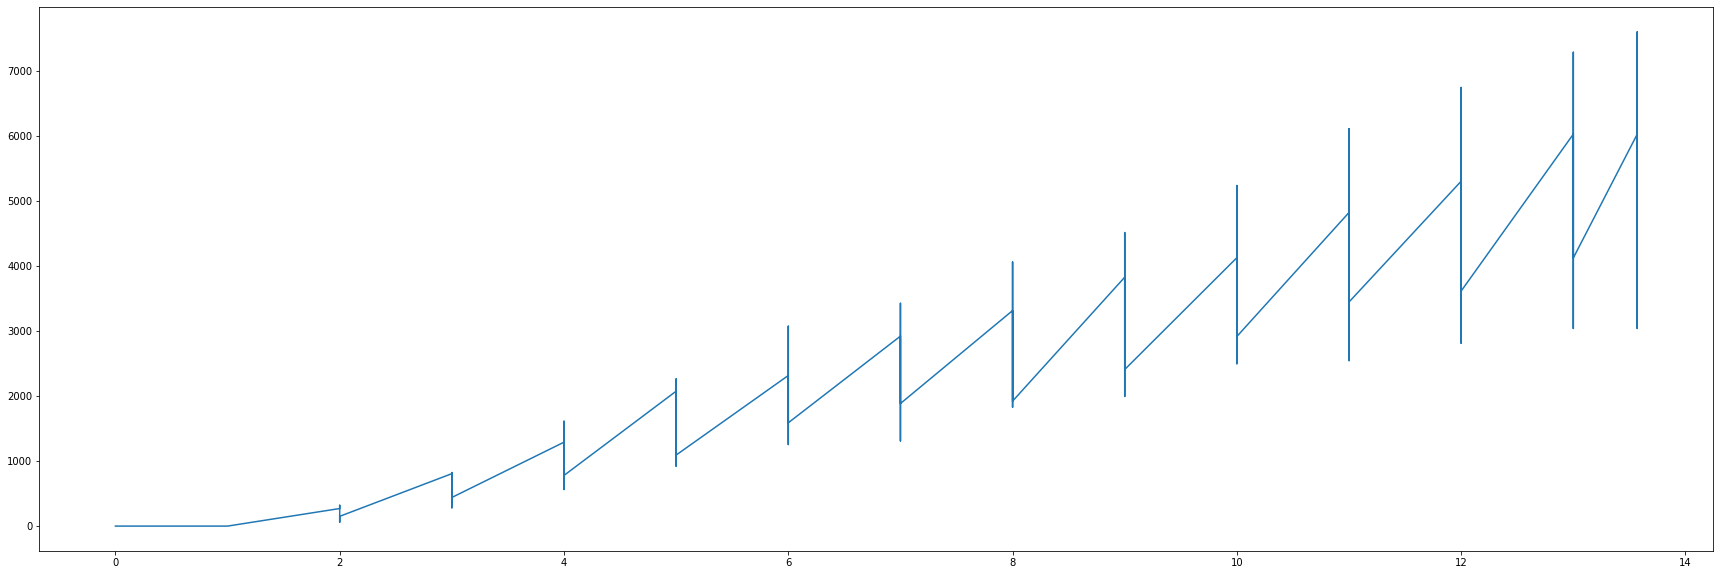

In [267]:
plt.figure(figsize = (30,10))
plt.plot(game_timeline_df['timestamp'] , game_timeline_df['xp'])
plt.show()